Importerar alla libraries som krävs för att kunna utföra statistisk analys.

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Läser in vår data från en csv fil mha. pandas.

In [12]:
customer_data = pd.read_csv('customerdata4.csv')
customer_data.head()

,CustomerID,Gender,Age,Annual Income (10kkr),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Describe gör så att man kan se vad det är för typ av data man arbetar med. Metoden skriver ut vad för sorts data man har i olika format. Den är bra för att kunna få en överblick av datan.

In [13]:
customer_data.describe()

,CustomerID,Age,Annual Income (10kkr),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


En boxplot är ett typ av diagram som används för att visa hur data är fördelad på ett enkelt och tydligt sätt. 

Den första boxploten visar fördelningen av årsinkomst för män och kvinnor.
Vi kan se att kvinnorna har en lägre minsta gräns för inkomst men att båda kön delar samma högsta inkomst.
Medianen följer samma spår då männen tjänar lite mer än kvinnorna i genomsnitt.

Den andra boxploten visar åldersfördelningen mellan män och kvinnor.
Vi kan se att det är ett större urval av männens åldergrupp medans kvinnoras är snävare.
Medianen för åldern hos kvinnor är lägre vilket också kan förklara varför kvinnornas årsinkomst är lägre vid denna jämförelse.

Den tredje boxploten visar hur mycket män och kvinnor tenderar att spendera, baserat på deras “spending score” mellan 1 och 100.
Vi ser att båda kön delar samma median dock att männen har en lägre minimi spenderar-gräns och kvinnorna har en högre max-gräns.
Dock spenderar båda kön i genomsnitt lika mycket.

<function matplotlib.pyplot.show(close=None, block=None)>

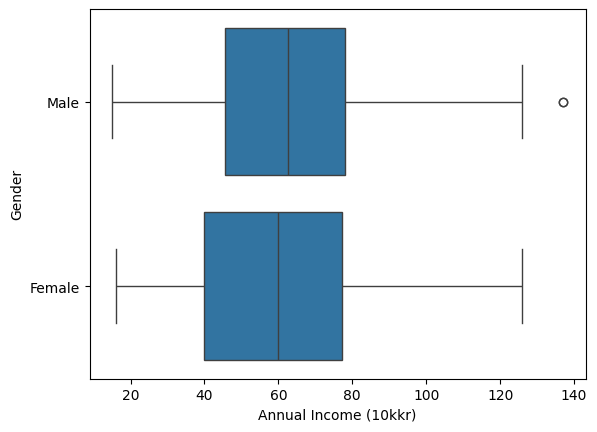

In [14]:

sns.boxplot(data=customer_data, x="Annual Income (10kkr)", y="Gender" )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

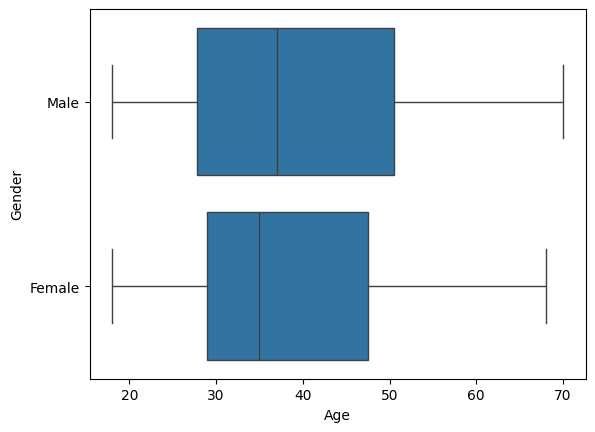

In [15]:
sns.boxplot(data=customer_data, x="Age", y="Gender" )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

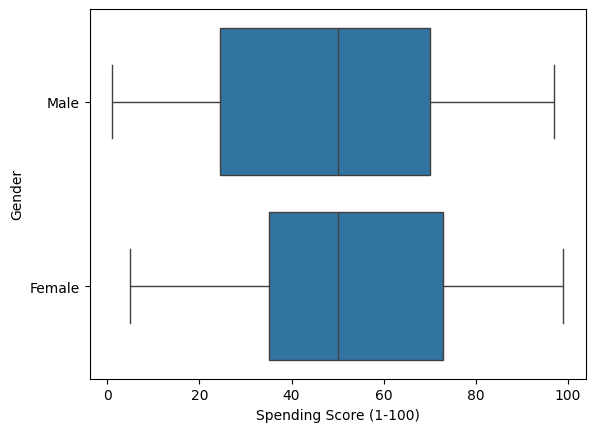

In [16]:
sns.boxplot(data=customer_data, x="Spending Score (1-100)", y="Gender" )
plt.show

Vi kan dra en slutsats om att den finns 4 väsentliga grupper mha. det valda k-värdet.
Man skulle dock kunna argumentera för att det finns 5 grupper genom att kolla på diagrammet och se att det blåa fältet är väldigt stort i jämförelse med de andra.

De fyra grupperna:
Uppe till vänster: En av de lägsta åldersgrupperna dock med högst spenderingsgrad. Mha. centroiden kan vi säga att denna grupp's medelålder är 30 och spenderingsgrad är 82.
Mitten vänster: Liknande åldersgrupp till blå men med lägre spenderingsgrad. Centroiden ger att åldergruppen är 27 och spenderingsgraden är 49.
Mitten höger: Samma spenderingsgrad som gul men med högre åldergrupp. Centroiden ger en åldersgrupp av 55 och en spenderingsgrad av 48.
Nederst: Denna grupp har den bredaste fördelningen i ålder och även lägst spenderingsgrad.

Centroider:
[[43.29166667 15.02083333]
 [30.1754386  82.35087719]
 [55.70833333 48.22916667]
 [27.61702128 49.14893617]]


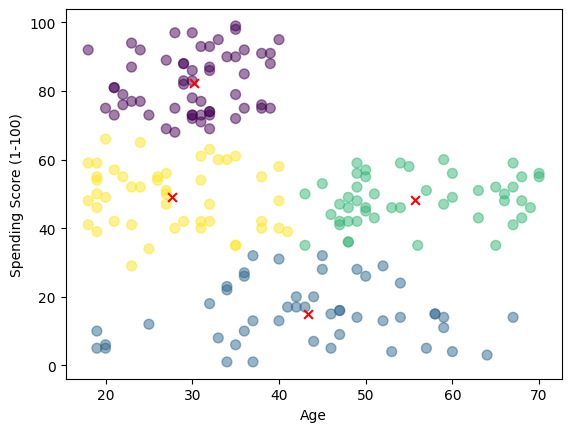

In [17]:
# Tuple Array for the points of Age and Spending Score
point = customer_data[['Age', 'Spending Score (1-100)']].values
xCoord = (point[:,0])
yCoord = (point[:,1])

k = 4

kmeans_data = KMeans(n_clusters = k).fit(point)
kmeans = KMeans(n_clusters = k, init = 'k-means++').fit(point)

centroids = kmeans_data.cluster_centers_
print("Centroider:")
print(centroids)

plt.scatter(point[:,0], point[:,1], c= kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=40,marker='x')
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

Här har vi en elbow-metod som vi kan bestämma ett k-värde utifrån. Från vad vi kan tyda så verkar det som att ett k-värde av fyra är bäst för denna analys.
Detta värde läser vi ut från var diagrammets trendlinje börjar plana ut.

Text(0, 0.5, 'Sum of squared distance')

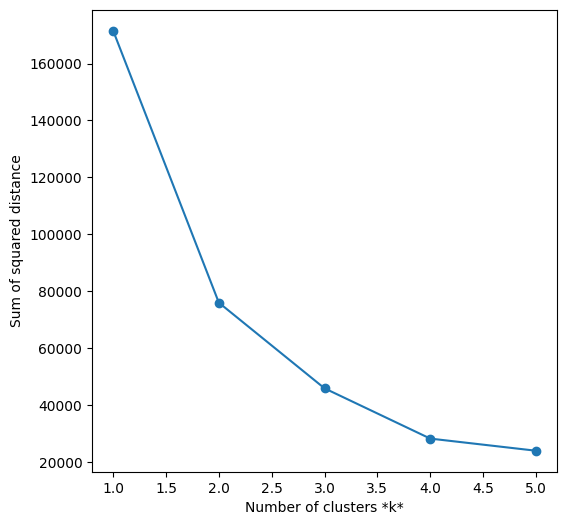

In [18]:
X = np.stack((xCoord, yCoord), axis=-1)
sse = []
# k_list is the list of range in between we want to find clusters for
k_list = list(range(1, 6))

for k in k_list:
    # km_model is the KMeans where we define the model for fitting the data
    km_model = KMeans(n_clusters=k)
    # fitting the data (X is the data set) to km_model
    km_model.fit(X)
    sse.append(km_model.inertia_)

# Plot sse against k and find the value of k where it starts to flatten down and make angle like elbow.
plt.figure(figsize=(6, 6))
plt.plot(k_list, sse, '-o')
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance')


Vi kan dra en slutsats om att den finns 5 väsentliga grupper mha. det valda k-värdet.
De fem grupperna:
Kluster "Uppe till vänster": Denna grupp har delad högst spenderingsgrad och delad lägst årsinkomst.
Kluster "Uppe till höger": Även Denna grupp har högst spenderingsgrad dock delad högsta årsinkomst
Kluster "Mitten": Denna grupp har ett mittenvärde för både åldergrupp och spenderingsgrad.
Kluster "Nere till vänster": Delad lägst årsinkomst med delad lägst spenderingsgrad.
Kluster "Nere till höger": Delad högsta årsinkomst och delad lägsta spenderingsgrad.


[[87.75       17.58333333]
 [55.0875     49.7125    ]
 [86.53846154 82.12820513]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]]


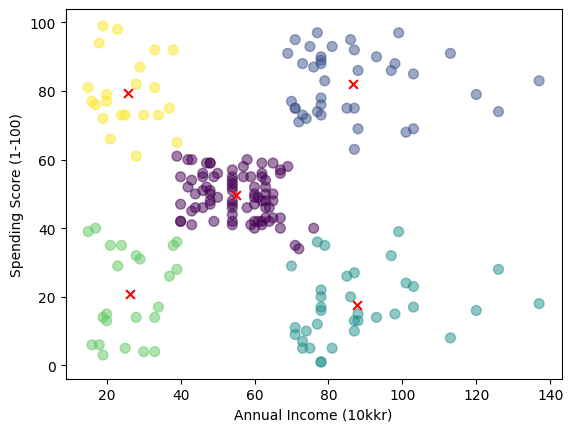

In [19]:
# Tuple Array for the points of Annual income and Spending Score
point = customer_data[['Annual Income (10kkr)', 'Spending Score (1-100)']].values
xCoord = (point[:,0])
yCoord = (point[:,1])

k = 5

kmeans_data = KMeans(n_clusters = k).fit(point)
kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state=0).fit(point)

centroids = kmeans_data.cluster_centers_
print(centroids)
plt.xlabel("Annual Income (10kkr)")
plt.ylabel("Spending Score (1-100)")
plt.scatter(point[:,0], point[:,1], c= kmeans.labels_.astype(float), s=50, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=40,marker='x')
plt.show()

Även här använder vi elbow-metoden för att kunna bestämma ett k-värde. Från vad vi kan tyda så verkar det som att ett k-värde av fem är bäst för denna analys.
Detta värde läser vi ut från var diagrammets trendlinje börjar plana ut.

Text(0, 0.5, 'Sum of squared distance')

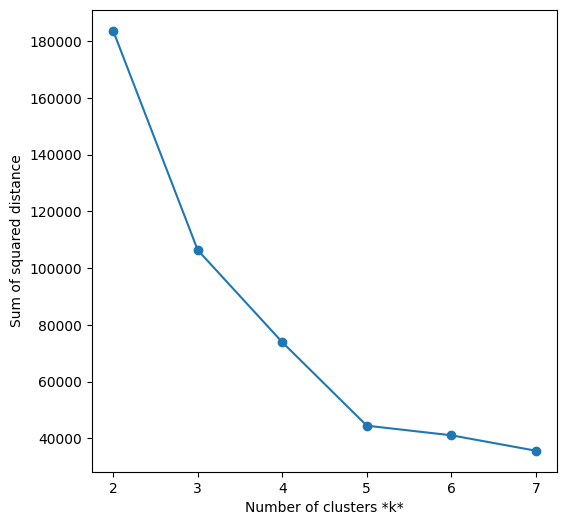

In [20]:
X = np.stack((xCoord, yCoord), axis=-1)
sse = []
# k_list is the list of range in between we want to find clusters for
k_list = list(range(2, 8))

for k in k_list:
    # km_model is the KMeans where we define the model for fitting the data
    km_model = KMeans(n_clusters=k)
    # fitting the data (X is the data set) to km_model
    km_model.fit(X)
    sse.append(km_model.inertia_)

# Plot sse against k and find the value of k where it starts to flatten down and make angle like elbow.
plt.figure(figsize=(6, 6))
plt.plot(k_list, sse, '-o')
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance')